<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/SN2026aaiv_spectre_Alpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SN 2026aaiv (NGC 7331) — visualisation colorisée et analyse d'un spectre Alpy 600

Notebook de visualisation d'un spectre 1D au format FITS (sortie ISIS) :

1. colorisation de l'aire sous la courbe selon la perception visuelle (CIE 1931 → sRGB) ;
2. annotation des raies caractéristiques d'une SN Ia, avec minima mesurés et vitesses ;
3. zoom sur Hα au décalage de la galaxie hôte ;
4. pseudo-largeurs équivalentes de Si II 5972 et 6355, rapport R(Si II) et diagramme de Branch.

Observation : Newton 200 + Alpy 600 (fente 23 µm) + Atik 414EX, site de Lias, 6 × 600 s, R ≈ 485.

## 1 — Chargement du spectre

In [1]:
import numpy as np, matplotlib.pyplot as plt, os
from matplotlib.patches import Polygon
from astropy.io import fits
from scipy.ndimage import uniform_filter1d

trapz = getattr(np, "trapezoid", None) or np.trapz          # numpy >= 2 / < 2
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

FITS_PATH = "_sn2026aaiv_20260912_901.fits"   # <- adapter si besoin

if not os.path.exists(FITS_PATH):
    try:                                       # Colab : ouvrir le sélecteur de fichier
        from google.colab import files
        FITS_PATH = list(files.upload().keys())[0]
    except ImportError:
        raise FileNotFoundError(FITS_PATH)

hdu  = fits.open(FITS_PATH)[0]
hdr  = hdu.header
flux = hdu.data.astype(float)
wave = hdr["CRVAL1"] + hdr["CDELT1"] * (np.arange(flux.size) + 1 - hdr.get("CRPIX1", 1))

OBJET   = hdr.get("OBJNAME", "?")
DATEOBS = hdr.get("DATE-OBS", "?")[:10]
Z_HOTE  = 0.00272          # NGC 7331, cz = 816 km/s
C_KMS   = 299792.458

print(f"{OBJET}  {DATEOBS}   {wave[0]:.1f} - {wave[-1]:.1f} A "
      f"({hdr['CDELT1']} A/px, {flux.size} px)   R = {hdr.get('BSS_ITRP', '?')}")
print(f"{hdr.get('EXPTIME2','')}  |  {hdr.get('BSS_INST','')}  |  site {hdr.get('BSS_SITE','')}")

Saving _sn2026aaiv_20260912_901.fits to _sn2026aaiv_20260912_901.fits
SN2026aaiv  2026-09-12   3805.5 - 7387.0 A (0.5 A/px, 7164 px)   R = 485
6 x 600 s  |  Newton 200 Alpy 600 slit 23?m Atik414EX  |  site Lias


## 2 — Colorimétrie : longueur d'onde → couleur perçue

Chaîne standard λ → XYZ → sRGB. Les fonctions colorimétriques CIE 1931 (observateur 2°) sont
calculées par l'approximation multi-lobes de Wyman, Sloan & Shirley (2013), précise à ~1 % dans
le visible et qui évite d'embarquer une table externe.

Deux réglages :

* `GAMMA` — contraste de la modulation par le flux. Les creux d'absorption assombrissent
  localement la couleur. `GAMMA = 0` supprime la modulation (teinte pleine partout).
* `EYE` — dosage de la sensibilité photopique V(λ). À 0, arc-en-ciel complet sur tout le
  domaine ; à 1, réponse de l'œil intégrale et extrémités quasi éteintes.

La teinte est figée hors de 400–660 nm : au-delà les fonctions colorimétriques tendent vers zéro,
l'approximation analytique y dérive et le rouge lointain virerait à l'orange.

In [2]:
def _lobe(x, mu, s1, s2):
    s = np.where(x < mu, s1, s2)
    return np.exp(-0.5 * ((x - mu) / s) ** 2)

def cie_xyz(lam_nm):
    """Fonctions colorimétriques CIE 1931 2 deg (Wyman, Sloan & Shirley 2013)."""
    x = (1.056 * _lobe(lam_nm, 599.8, 37.9, 31.0)
         + 0.362 * _lobe(lam_nm, 442.0, 16.0, 26.7)
         - 0.065 * _lobe(lam_nm, 501.1, 20.4, 26.2))
    y = (0.821 * _lobe(lam_nm, 568.8, 46.9, 40.5)
         + 0.286 * _lobe(lam_nm, 530.9, 16.3, 31.1))
    z = (1.217 * _lobe(lam_nm, 437.0, 11.8, 36.0)
         + 0.681 * _lobe(lam_nm, 459.0, 26.0, 13.8))
    return np.stack([x, y, z], axis=-1)

XYZ2RGB = np.array([[ 3.2406, -1.5372, -0.4986],
                    [-0.9689,  1.8758,  0.0415],
                    [ 0.0557, -0.2040,  1.0570]])

def _srgb_gamma(c):
    c = np.clip(c, 0, 1)
    return np.where(c <= 0.0031308, 12.92 * c, 1.055 * c ** (1 / 2.4) - 0.055)

def spectre_rgb(lam_A, f, gamma=0.7, eye=0.3):
    """Couleur sRGB de chaque colonne : teinte de la longueur d'onde, luminance
    (flux/flux_max)**gamma * V(lambda)**eye."""
    lam_nm = lam_A / 10.0
    xyz = cie_xyz(np.clip(lam_nm, 400., 660.))       # teinte figee hors [400, 660] nm
    rgb = np.maximum(xyz @ XYZ2RGB.T, 0.0)
    mx  = rgb.max(axis=1, keepdims=True)
    teinte = np.where(mx > 1e-9, rgb / np.maximum(mx, 1e-9), 0.0)

    V = cie_xyz(lam_nm)[:, 1]
    V = V / V.max()
    lum = (np.clip(f, 0, None) / np.nanmax(f)) ** gamma * V ** eye
    return _srgb_gamma(teinte * (lum / np.nanmax(lum))[:, None])

## 3 — Tracé colorisé

`LISSAGE` ne sert qu'au calcul des couleurs et au contour de l'aire remplie : sans lui le bruit
pixel à pixel crée des stries verticales dans le dégradé. La courbe tracée par-dessus reste
le spectre brut.

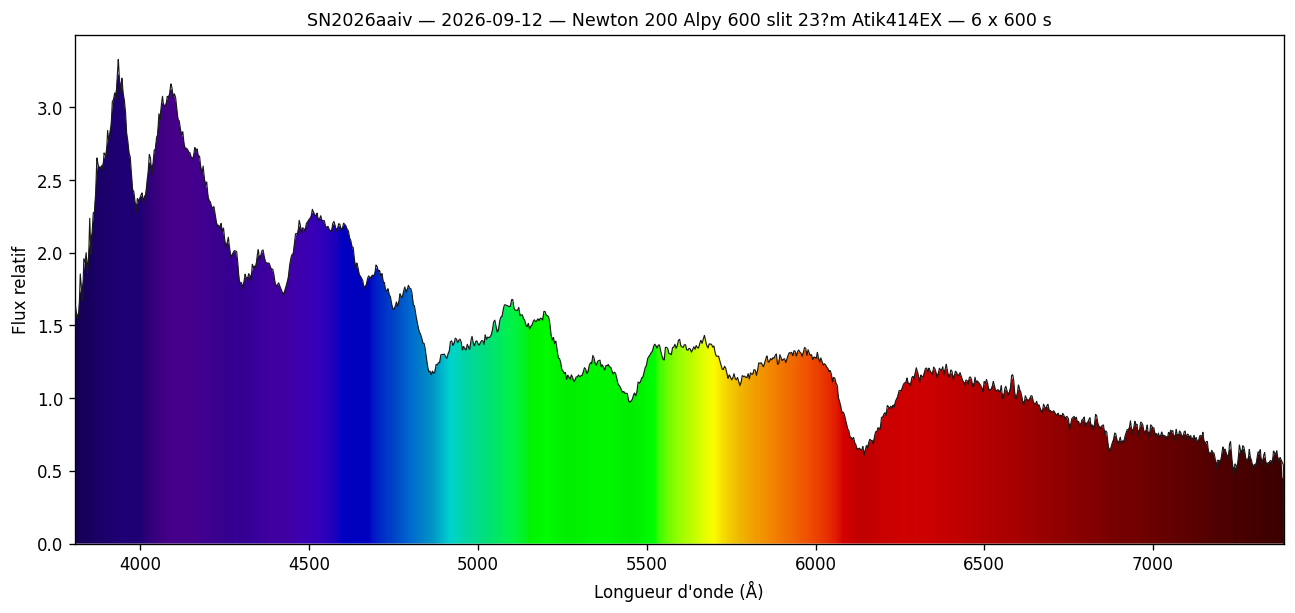

In [12]:
GAMMA   = 0.5      # contraste de la modulation par le flux (0 = teinte pleine)
EYE     = 0.3      # part de sensibilite photopique (0 = arc-en-ciel plein, 1 = oeil complet)
LISSAGE = 21       # px, pour la couleur et le contour de l'aire seulement

flux_l = uniform_filter1d(flux, LISSAGE)

def trace_spectre(ax, gamma=GAMMA, eye=EYE, ymax=None, courbe=True):
    """Remplit l'aire sous la courbe avec le degrade spectral."""
    ymax = ymax or np.nanmax(flux) * 1.05
    rgb  = spectre_rgb(wave, flux_l, gamma=gamma, eye=eye)
    img  = ax.imshow(np.tile(rgb[None], (2, 1, 1)), aspect="auto", origin="lower",
                     extent=[wave[0], wave[-1], 0, ymax], interpolation="bilinear", zorder=0)
    contour = np.column_stack([np.r_[wave[0], wave, wave[-1]], np.r_[0, flux_l, 0]])
    img.set_clip_path(Polygon(contour, transform=ax.transData, closed=True))
    if courbe:
        ax.plot(wave, flux, lw=0.7, color="0.10", zorder=3)
    ax.set_xlim(wave[0], wave[-1]); ax.set_ylim(0, ymax)
    ax.set_xlabel("Longueur d'onde (Å)"); ax.set_ylabel("Flux relatif")
    return ymax

fig, ax = plt.subplots(figsize=(13, 5.5))
trace_spectre(ax)
ax.set_title(f"{OBJET} — {DATEOBS} — {hdr.get('BSS_INST','')} — {hdr.get('EXPTIME2','')}",
             fontsize=10.5)
plt.show()

## 4 — Raies annotées

Table éditable. Chaque entrée donne la longueur d'onde au repos, la fenêtre de recherche du
minimum (en longueur d'onde observée, donc décalée vers le bleu par l'expansion), le libellé et
le niveau d'étiquette (0, 1 ou 2) pour éviter les chevauchements.

`blend=True` supprime l'affichage de la vitesse : le minimum d'un mélange de raies ne suit pas
la photosphère et la vitesse qu'on en tirerait n'aurait pas de sens physique.

In [13]:
# (lambda_repos, fenetre de recherche du minimum, libelle, niveau, blend)
RAIES = [
    (4130, (3940, 4080), "Si II 4130",     2, False),
    (4481, (4150, 4400), "Mg II 4481",     1, True ),
    (5000, (4750, 4950), "Fe II / Fe III", 0, True ),
    (5454, (5150, 5330), "S II 5454",      1, False),
    (5640, (5350, 5520), "S II 5640",      2, False),
    (5972, (5700, 5850), "Si II 5972",     0, False),
    (6355, (6000, 6250), "Si II 6355",     1, False),
]

flux_min = uniform_filter1d(flux, 61)      # lissage plus fort pour localiser les minima

def minimum(fen):
    m = (wave >= fen[0]) & (wave <= fen[1])
    return wave[m][np.argmin(flux_min[m])]

def vitesse(lam_repos, lam_obs):
    """Vitesse d'expansion, dans le referentiel de la galaxie hote."""
    lam0 = lam_repos * (1 + Z_HOTE)
    return (lam0 - lam_obs) / lam0 * C_KMS

mesures = []
for lam0, fen, lab, niv, blend in RAIES:
    w = minimum(fen)
    mesures.append(dict(lam0=lam0, obs=w, v=vitesse(lam0, w), label=lab, niveau=niv, blend=blend))

print(f"{'raie':16s}{'min obs (A)':>13s}{'v (km/s)':>12s}")
for m in mesures:
    v = "—  (blend)" if m["blend"] else f"{m['v']:8.0f}"
    print(f"{m['label']:16s}{m['obs']:13.1f}{v:>12s}")

v_phot = np.mean([m["v"] for m in mesures if not m["blend"]])
print(f"\nvitesse photospherique moyenne (Si II + S II) : {v_phot:.0f} km/s")

raie              min obs (A)    v (km/s)
Si II 4130             3997.5       10405
Mg II 4481             4306.5  —  (blend)
Fe II / Fe III         4865.5  —  (blend)
S II 5454              5276.5       10543
S II 5640              5454.5       10647
Si II 5972             5766.0       11126
Si II 6355             6135.5       11140

vitesse photospherique moyenne (Si II + S II) : 10772 km/s


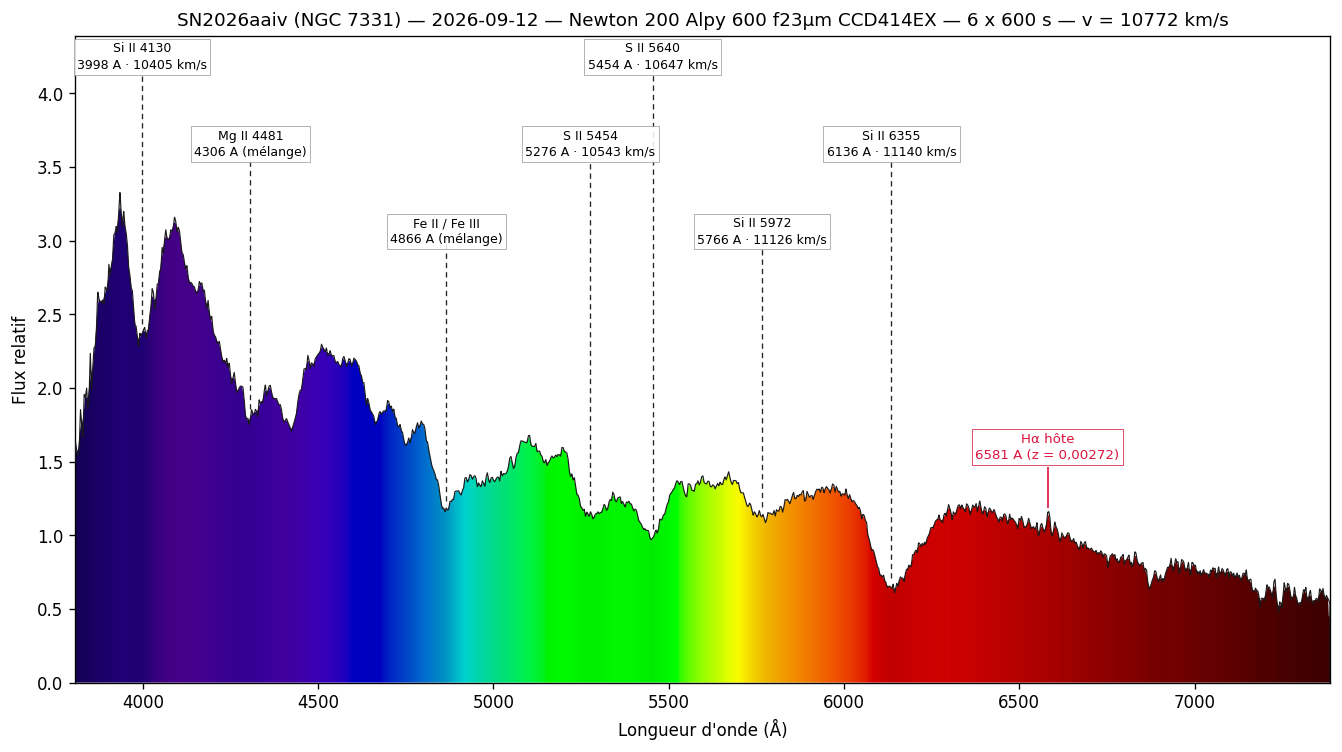

In [18]:
NIVEAUX = (0.72, 0.855, 0.99)      # hauteurs des etiquettes, en fraction de l'axe

fig, ax = plt.subplots(figsize=(13.5, 7))
ymax = trace_spectre(ax, ymax=np.nanmax(flux) * 1.32)

for m in mesures:
    txt = f"{m['label']}\n{m['obs']:.0f} A"
    if not m["blend"]:
       #  txt += (" · %.1f" % (m["v"] / 1000)).replace(".", ",") + "×10³ km/s"
       txt += f" · {m['v']:.0f} km/s"
    else:
        txt += " (mélange)"
    y0   = np.interp(m["obs"], wave, flux_l)
    ytxt = ymax * NIVEAUX[m["niveau"]]
    ax.vlines(m["obs"], y0 + 0.06, ytxt - 0.14, color="0.15", lw=0.8, ls=(0, (4, 3)), zorder=4)
    ax.text(m["obs"], ytxt, txt, ha="center", va="top", fontsize=7.5, zorder=5, linespacing=1.3,
            bbox=dict(fc="white", ec="0.6", lw=0.5, alpha=0.88, pad=2))

# Halpha au decalage de l'hote
w_ha = 6562.8 * (1 + Z_HOTE)
y_ha = np.interp(w_ha, wave, flux_l)
ax.vlines(w_ha, y_ha + 0.06, y_ha + 0.34, color="crimson", lw=1.0, zorder=4)
ax.text(w_ha, y_ha + 0.38, f"Hα hôte\n{w_ha:.0f} A (z = {Z_HOTE:.5f})".replace(".", ","),
        ha="center", va="bottom", fontsize=8, color="crimson", zorder=5, linespacing=1.3,
        bbox=dict(fc="white", ec="crimson", lw=0.5, alpha=0.88, pad=2))

ax.set_title(f"{OBJET} (NGC 7331) — {DATEOBS} — Newton 200 Alpy 600 f23µm CCD414EX — "
             f"{hdr.get('EXPTIME2','')} — v = {v_phot:.0f} km/s", fontsize=11)
plt.show()

## 5 — Zoom sur Hα de la galaxie hôte

Le spectre est divisé par un continu lissé sur 201 px (100 Å), ce qui aplatit les larges bandes
de la supernova et fait ressortir une éventuelle raie étroite non résolue. L'écart-type des
résidus sur une fenêtre voisine sans raie sert de niveau de bruit.

Hα           attendu  6580.7 A   pic +11.6 %   soit  6.1 sigma
[N II] 6583  attendu  6601.3 A   pic  +5.9 %   soit  3.1 sigma
[N II] 6548  attendu  6565.8 A   pic  +2.2 %   soit  1.1 sigma


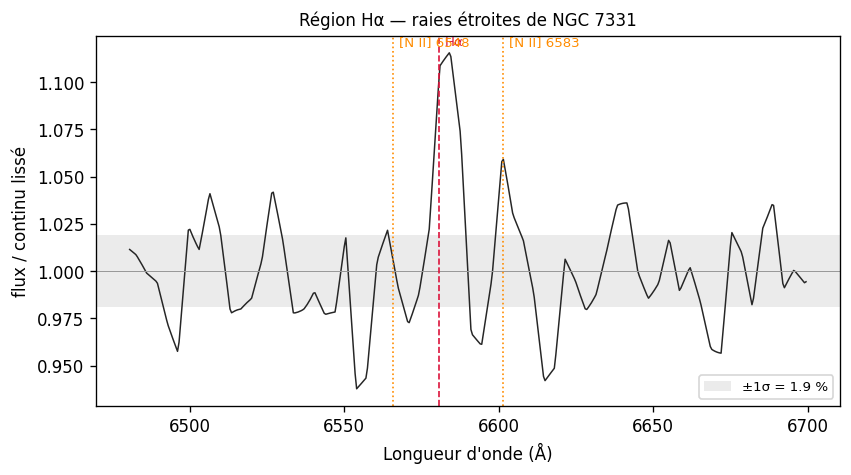

In [19]:
continu = uniform_filter1d(flux, 201)
ratio   = flux / continu

FEN_BRUIT = (6400, 6520)
mb   = (wave >= FEN_BRUIT[0]) & (wave <= FEN_BRUIT[1])
bruit = np.std(ratio[mb])

raies_hote = [(6562.8, "Hα",          "crimson",    "--"),
              (6583.4, "[N II] 6583", "darkorange", ":" ),
              (6548.0, "[N II] 6548", "darkorange", ":" )]

fig, ax = plt.subplots(figsize=(8, 4))
m = (wave > 6480) & (wave < 6700)
ax.plot(wave[m], ratio[m], lw=0.9, color="0.15")
ax.axhline(1, color="0.6", lw=0.6)
ax.axhspan(1 - bruit, 1 + bruit, color="0.7", alpha=0.25, lw=0, label=f"±1σ = {bruit*100:.1f} %")

for lam0, lab, col, ls in raies_hote:
    w0 = lam0 * (1 + Z_HOTE)
    ax.axvline(w0, color=col, lw=1, ls=ls)
    ax.text(w0 + 2, ax.get_ylim()[1], lab, color=col, fontsize=8, va="top")
    fen = (wave > w0 - 8) & (wave < w0 + 8)
    pic = ratio[fen].max()
    print(f"{lab:12s} attendu {w0:7.1f} A   pic {(pic-1)*100:+5.1f} %   "
          f"soit {(pic-1)/bruit:4.1f} sigma")

ax.set_xlabel("Longueur d'onde (Å)"); ax.set_ylabel("flux / continu lissé")
ax.set_title("Région Hα — raies étroites de NGC 7331", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
plt.show()

## 6 — Pseudo-largeurs équivalentes et rapport R(Si II)

Un spectre de supernova n'a pas de continu vrai : on définit un **pseudo-continu**, la droite
joignant les deux maxima d'émission qui encadrent l'absorption, et on intègre le déficit de flux
sous cette droite.

La mesure est locale, donc peu sensible aux erreurs de réponse instrumentale ou d'extinction, qui
se réduisent sur 200 Å à une pente absorbée par le pseudo-continu — et les creux font 100 à 200 Å
de large, soit une quinzaine de fois l'élément spectral de l'Alpy.

* **R(Si II) = pEW(5972) / pEW(6355)** (Nugent et al. 1995) est corrélé à Δm₁₅(B), donc à la
  luminosité au maximum : R ≈ 0,2 pour une Ia lumineuse à déclin lent, R ≈ 0,5–0,6 pour une
  91bg sous-lumineuse.
* Le plan **pEW(5972) vs pEW(6355)** est le diagramme de Branch et al. (2006), qui répartit les
  Ia en quatre familles : Core Normal, Broad Line, Cool, Shallow Silicon.

Réserves : la calibration en Δm₁₅ ne vaut qu'à quelques jours du maximum, et Si II 5972 est peu
profond — c'est lui qui porte l'essentiel de l'incertitude.

In [ ]:
# fenetres de recherche des maxima du pseudo-continu (longueurs d'onde observees)
FEN_BLEU_5972 = (5600, 5720)
FEN_PIVOT     = (5850, 6030)      # maximum commun aux deux raies
FEN_ROUGE_6355 = (6250, 6500)

def maximum(fen, y=None):
    y = flux_min if y is None else y
    m = (wave >= fen[0]) & (wave <= fen[1])
    return wave[m][np.argmax(y[m])]

def pew(w_bleu, w_rouge, y):
    """Pseudo-largeur equivalente entre deux ancres du pseudo-continu."""
    f_b, f_r = np.interp(w_bleu, wave, y), np.interp(w_rouge, wave, y)
    m  = (wave >= w_bleu) & (wave <= w_rouge)
    pc = f_b + (f_r - f_b) * (wave[m] - w_bleu) / (w_rouge - w_bleu)
    return trapz(1 - y[m] / pc, wave[m])

a_bleu, a_pivot, a_rouge = maximum(FEN_BLEU_5972), maximum(FEN_PIVOT), maximum(FEN_ROUGE_6355)
pew_5972 = pew(a_bleu,  a_pivot, flux_min)
pew_6355 = pew(a_pivot, a_rouge, flux_min)

# incertitude : bruit du spectre + deplacement aleatoire des ancres de +/- 15 A
rms = np.std(flux - flux_min)
rng = np.random.default_rng(0)
tir = []
for _ in range(400):
    y = uniform_filter1d(flux + rng.normal(0, rms, flux.size), 61)
    j = rng.uniform(-15, 15, 3)
    tir.append((pew(a_bleu + j[0], a_pivot + j[1], y),
                pew(a_pivot + j[1], a_rouge + j[2], y)))
tir = np.array(tir)
s5972, s6355 = tir.std(axis=0)
R      = pew_5972 / pew_6355
sigma_R = (tir[:, 0] / tir[:, 1]).std()

print(f"ancres du pseudo-continu : {a_bleu:.0f} / {a_pivot:.0f} / {a_rouge:.0f} A")
print(f"pEW(Si II 5972) = {pew_5972:5.1f} ± {s5972:.1f} A")
print(f"pEW(Si II 6355) = {pew_6355:5.1f} ± {s6355:.1f} A")
print(f"R(Si II)        = {R:5.3f} ± {sigma_R:.3f}")

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- pseudo-continus ---
a1.plot(wave, flux, lw=0.6, color="0.6")
a1.plot(wave, flux_min, lw=1.0, color="0.1")
for wb, wr, col, lab in [(a_bleu, a_pivot, "tab:blue", "Si II 5972"),
                         (a_pivot, a_rouge, "tab:red", "Si II 6355")]:
    fb, fr = np.interp(wb, wave, flux_min), np.interp(wr, wave, flux_min)
    m = (wave >= wb) & (wave <= wr)
    pc = fb + (fr - fb) * (wave[m] - wb) / (wr - wb)
    a1.plot([wb, wr], [fb, fr], color=col, lw=1.2)
    a1.fill_between(wave[m], flux_min[m], pc, color=col, alpha=0.25, lw=0, label=lab)
a1.set_xlim(5550, 6550); a1.set_ylim(0.5, 1.6)
a1.set_xlabel("Longueur d'onde (Å)"); a1.set_ylabel("Flux relatif")
a1.set_title("Pseudo-continus et aires intégrées", fontsize=10); a1.legend(fontsize=8)

# --- diagramme de Branch ---
a2.axvline(105, color="0.7", lw=0.8); a2.axvline(70, color="0.7", lw=0.8)
a2.axhline(30, color="0.7", lw=0.8)
for x, y, t in [(88, 12, "Core Normal"), (135, 12, "Broad Line"),
                (50, 12, "Shallow Si"), (110, 45, "Cool")]:
    a2.text(x, y, t, ha="center", fontsize=8.5, color="0.35")
a2.errorbar(pew_6355, pew_5972, xerr=s6355, yerr=s5972, fmt="o", color="crimson",
            ms=7, capsize=3, zorder=5, label=OBJET)
a2.set_xlim(20, 180); a2.set_ylim(0, 60)
a2.set_xlabel("pEW(Si II 6355)  [Å]"); a2.set_ylabel("pEW(Si II 5972)  [Å]")
a2.set_title("Diagramme de Branch et al. (2006)", fontsize=10); a2.legend(fontsize=8)

plt.tight_layout(); plt.show()

## Références

* Wyman, Sloan & Shirley (2013), *Simple analytic approximations to the CIE XYZ color matching
  functions*, JCGT 2(2).
* Nugent, Phillips, Baron, Branch & Hauschildt (1995), ApJ 455, L147 — rapport R(Si II).
* Branch et al. (2006), PASP 118, 560 — classification pEW(5972) vs pEW(6355).
* Wang et al. (2009), ApJ 699, L139 — séparation Normal / High-Velocity à v(Si II) ≈ 11 800 km/s.